# Assignment 2: Ablating Equivariance — Starter Code

This notebook provides:
1. A charged particle dynamics dataset
2. A working EGNN with velocity integration (the model you'll ablate)
3. A training loop
4. A trajectory visualization utility

In [28]:
import flax.linen as nn
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["font.size"] = 12

---
## 1. Charged Particle Dynamics Dataset

We simulate a system of charged particles interacting via Coulomb forces. Each sample consists of:
- **Input:** Initial positions $x_i(0)$ and velocities $v_i(0)$ for $N$ particles, plus their charges
- **Target:** Positions $x_i(T)$ after $T = 1000$ time steps of Coulomb dynamics

The physics: particles with charges $q_i \in \{-1, +1\}$ exert Coulomb forces on each other:
$$F_{ij} = q_i q_j \frac{x_i - x_j}{\|x_i - x_j\|^3}$$

Like charges repel, opposite charges attract. The dynamics are governed by Newton's second law, integrated using the Velocity Verlet scheme.

This is a natural testbed for equivariant networks because:
- The forces depend only on relative positions (translation invariant)
- Rotating all positions rotates all forces (rotation equivariant)
- The velocity channel adds temporal structure beyond static geometry
- Predicting long-horizon dynamics requires understanding both the initial momentum *and* the force interactions

In [29]:
def generate_charged_particles(key, n_samples=6400, n_particles=10, dt=0.001, n_steps=1000):
    """Generate a dataset of charged particle dynamics.

    Each sample: N particles with random positions, velocities, and charges.
    We simulate n_steps of Coulomb dynamics and predict the final positions.

    Returns:
        Dictionary with pos, vel, node_feat, edges, and target_pos.
    """
    k1, k2, k3 = jr.split(key, 3)

    pos = jr.normal(k1, (n_samples, n_particles, 3)) * 1.0
    vel = jr.normal(k2, (n_samples, n_particles, 3)) * 0.1
    charges = jr.choice(k3, jnp.array([-1.0, 1.0]), shape=(n_samples, n_particles))

    # Fully connected graph (every particle interacts with every other)
    edges = jnp.ones((n_particles, n_particles)) - jnp.eye(n_particles)
    edges = jnp.broadcast_to(edges, (n_samples, n_particles, n_particles))

    def simulate(pos_i, vel_i, charges_i):
        """Integrate one system forward in time."""

        def one_step(carry, _):
            p, v = carry
            rel = p[:, None, :] - p[None, :, :]
            dist_sq = jnp.sum(rel**2, axis=-1, keepdims=True)
            dist = jnp.sqrt(jnp.maximum(dist_sq, 0.25))  # soft cutoff
            charge_prod = charges_i[:, None] * charges_i[None, :]
            force = charge_prod[:, :, None] * rel / (dist**3)
            mask_diag = 1.0 - jnp.eye(len(charges_i))[:, :, None]
            force = (force * mask_diag).sum(axis=1)
            v_new = v + force * dt
            p_new = p + v_new * dt
            return (p_new, v_new), None

        (pos_final, _), _ = jax.lax.scan(one_step, (pos_i, vel_i), None, length=n_steps)
        return pos_final

    target_pos = jax.vmap(simulate)(pos, vel, charges)

    # Node features: one-hot charge encoding
    node_feat = jnp.stack(
        [
            (charges == -1.0).astype(jnp.float32),
            (charges == 1.0).astype(jnp.float32),
        ],
        axis=-1,
    )

    disp = jnp.abs(target_pos - pos)
    print(f"Generated {n_samples} systems, {n_steps} steps (total time = {dt * n_steps:.2f})")
    print(f"Mean displacement: {float(disp.mean()):.4f}, Max: {float(disp.max()):.4f}")

    return {
        "pos": np.array(pos),
        "vel": np.array(vel),
        "node_feat": np.array(node_feat),
        "edges": np.array(edges),
        "target_pos": np.array(target_pos),
    }


data = generate_charged_particles(jr.PRNGKey(42), n_samples=6400, n_particles=10)

n_train = 2400
train_data = {k: v[:n_train] for k, v in data.items()}
val_data = {k: v[n_train:] for k, v in data.items()}

print(f"\nTrain: {n_train}, Val: {len(data['pos']) - n_train}")
print(f"Particles per system: {data['pos'].shape[1]}")
print(f"Position shape: {data['pos'].shape}")
print(f"Velocity shape: {data['vel'].shape}")

Generated 6400 systems, 1000 steps (total time = 1.00)
Mean displacement: 0.2797, Max: 2.0094

Train: 2400, Val: 4000
Particles per system: 10
Position shape: (6400, 10, 3)
Velocity shape: (6400, 10, 3)


### Visualize the dataset

Particles with charges (red = +, blue = −), edges between them, displacement arrows (solid), and velocity arrows (dashed).

/var/folders/fk/kt7njm6n07x1xlh8lppw23jr0000gp/T/ipykernel_97360/460077633.py:46: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter(


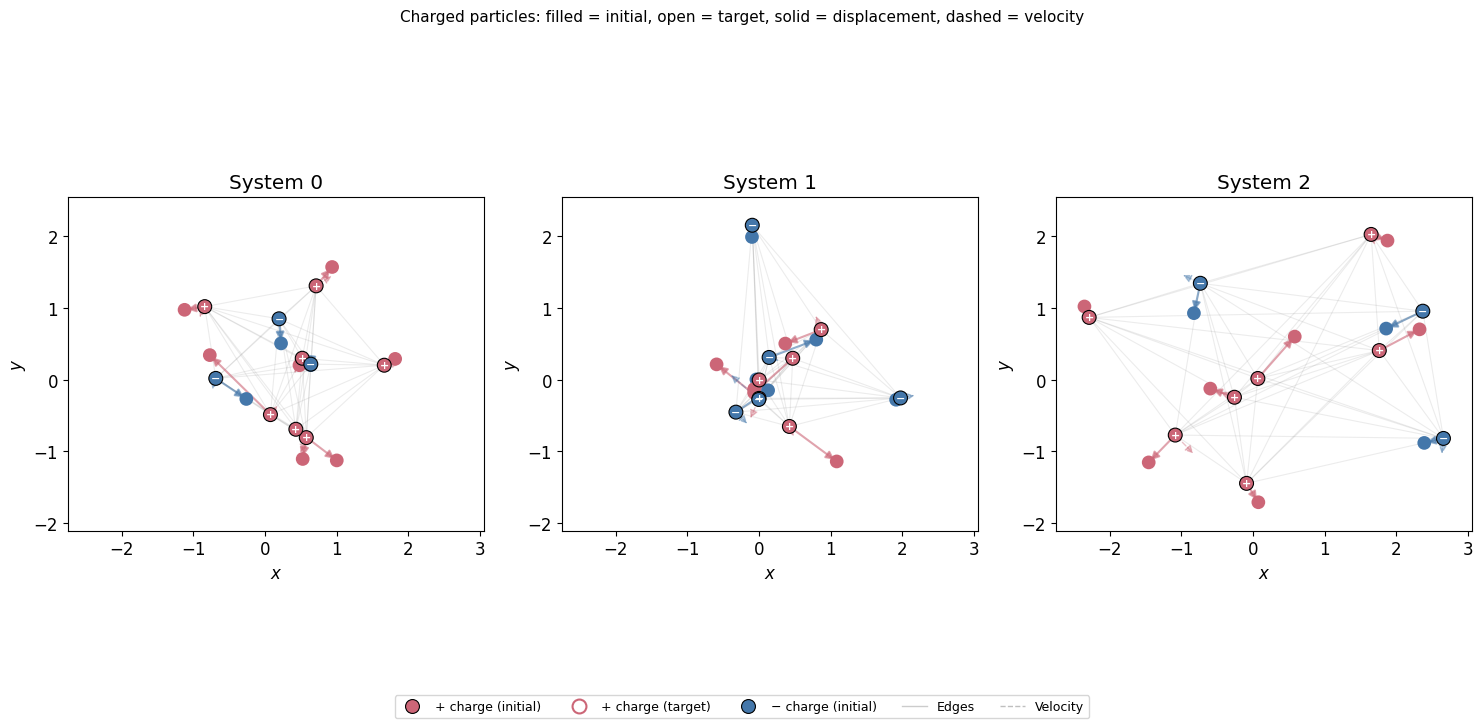

In [30]:
from matplotlib.lines import Line2D

n_show = 3
fig, axes = plt.subplots(1, n_show, figsize=(15, 6.5))

# Compute shared axis limits across all displayed systems
all_pts = np.concatenate([data["pos"][:n_show].reshape(-1, 3), data["target_pos"][:n_show].reshape(-1, 3)], axis=0)
pad = 0.4
xlim = (all_pts[:, 0].min() - pad, all_pts[:, 0].max() + pad)
ylim = (all_pts[:, 1].min() - pad, all_pts[:, 1].max() + pad)

for idx, ax in enumerate(axes):
    pos_i = data["pos"][idx]
    vel_i = data["vel"][idx]
    target_i = data["target_pos"][idx]
    charges_i = data["node_feat"][idx][:, 1] - data["node_feat"][idx][:, 0]
    n = len(pos_i)

    colors = ["#4477AA" if q < 0 else "#CC6677" for q in charges_i]

    # Edges
    for i in range(n):
        for j in range(i + 1, n):
            ax.plot([pos_i[i, 0], pos_i[j, 0]], [pos_i[i, 1], pos_i[j, 1]], color="gray", alpha=0.15, lw=0.8, zorder=1)

    # Displacement arrows: initial → target
    for j in range(n):
        ax.annotate(
            "",
            xy=(target_i[j, 0], target_i[j, 1]),
            xytext=(pos_i[j, 0], pos_i[j, 1]),
            arrowprops=dict(arrowstyle="-|>", color=colors[j], lw=1.5, alpha=0.6),
        )

    # Velocity arrows (dashed)
    vel_scale = 2.0
    for j in range(n):
        ax.annotate(
            "",
            xy=(pos_i[j, 0] + vel_i[j, 0] * vel_scale, pos_i[j, 1] + vel_i[j, 1] * vel_scale),
            xytext=(pos_i[j, 0], pos_i[j, 1]),
            arrowprops=dict(arrowstyle="-|>", color=colors[j], lw=1.0, linestyle="dashed", alpha=0.4),
        )

    # Target positions (open circles)
    ax.scatter(
        target_i[:, 0],
        target_i[:, 1],
        c=colors,
        s=70,
        marker="o",
        facecolors="none",
        edgecolors=colors,
        linewidths=1.5,
        zorder=4,
    )

    # Initial positions (filled circles)
    ax.scatter(pos_i[:, 0], pos_i[:, 1], c=colors, s=100, zorder=5, edgecolors="black", linewidths=0.8)

    # Charge labels
    for j in range(n):
        label = "+" if charges_i[j] > 0 else "\u2212"
        ax.annotate(
            label,
            (pos_i[j, 0], pos_i[j, 1]),
            fontsize=8,
            fontweight="bold",
            ha="center",
            va="center",
            color="white",
            zorder=6,
        )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.set_title(f"System {idx}")
    ax.set_aspect("equal")

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="#CC6677",
        markersize=10,
        markeredgecolor="black",
        markeredgewidth=0.8,
        label="+ charge (initial)",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="none",
        markersize=10,
        markeredgecolor="#CC6677",
        markeredgewidth=1.5,
        label="+ charge (target)",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="#4477AA",
        markersize=10,
        markeredgecolor="black",
        markeredgewidth=0.8,
        label="\u2212 charge (initial)",
    ),
    Line2D([0], [0], color="gray", alpha=0.4, lw=1, label="Edges"),
    Line2D([0], [0], color="gray", lw=1, linestyle="dashed", alpha=0.5, label="Velocity"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.08))
plt.suptitle(
    "Charged particles: filled = initial, open = target, solid = displacement, dashed = velocity", fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

---
## 2. EGNN with Velocity

This is the full EGNN with velocity integration — the model you will ablate. Read through it carefully before modifying anything.

Each message-passing layer:
1. **Computes messages** from sender/receiver features and pairwise squared distances
2. **Updates velocity** using relative vectors scaled by learned (bounded) scalars
3. **Updates features** with a residual MLP that aggregates incoming messages

After all layers, the final position is `x_out = x_in + v_final`.

In [31]:
D_HIDDEN = 64
D_MSG = 32
N_LAYERS = 4


class EGNN(nn.Module):
    """E(3) Equivariant GNN with velocity for dynamics prediction."""

    @nn.compact
    def __call__(self, node_feat, pos, vel, edges):
        """
        Args:
            node_feat: [batch, N, D_feat] node features (charge type)
            pos:       [batch, N, 3] initial positions
            vel:       [batch, N, 3] initial velocities
            edges:     [batch, N, N] adjacency (1 = edge, 0 = no edge)

        Returns:
            predicted positions [batch, N, 3]
        """
        h = nn.Dense(D_HIDDEN)(node_feat)  # embed node features
        x = pos
        v = vel

        for _ in range(N_LAYERS):
            # --- Pairwise geometry ---
            rel = x[:, :, None, :] - x[:, None, :, :]  # [batch, N, N, 3]
            dist_sq = jnp.sum(rel**2, axis=-1, keepdims=True)  # [batch, N, N, 1]

            # --- Messages from sender features, receiver features, and distances ---
            m_ij = nn.relu(
                nn.Dense(D_MSG)(h)[:, :, None, :]  # sender:   h_i → [batch, N, 1, D]
                + nn.Dense(D_MSG)(h)[:, None, :, :]  # receiver: h_j → [batch, 1, N, D]
                + nn.Dense(D_MSG)(dist_sq)  # geometry: d²  → [batch, N, N, D]
            )
            m_ij = m_ij * edges[:, :, :, None]  # zero out non-edges

            # --- Velocity update (learned acceleration) ---
            x_weight = jnp.tanh(nn.Dense(1)(m_ij))  # bounded scalar per edge
            coord_shift = (rel * x_weight * edges[:, :, :, None]).sum(axis=2)
            v = v + coord_shift

            # --- Feature update with residual ---
            agg = m_ij.sum(axis=2)  # aggregate messages
            h = h + nn.relu(nn.Dense(D_HIDDEN)(jnp.concatenate([h, agg], axis=-1)))

        # Integrate velocity → final positions
        x = x + v
        return x

---
## 3. Training Loop

Optimizes MSE between predicted and target positions. Use this for all your models.

In [32]:
def train_model(model, train_data, val_data, n_epochs=100, batch_size=64, lr=1e-3, seed=0):
    """Train a model and return params + per-epoch losses.

    The model must have signature: model(node_feat, pos, vel, edges) → predicted_pos.
    """
    key = jr.PRNGKey(seed)
    params = model.init(
        key, train_data["node_feat"][:1], train_data["pos"][:1], train_data["vel"][:1], train_data["edges"][:1]
    )

    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)

    @jax.jit
    def step(params, opt_state, node_feat, pos, vel, edges, target_pos):
        def loss_fn(p):
            pred = model.apply(p, node_feat, pos, vel, edges)
            return jnp.mean((pred - target_pos) ** 2)

        loss, grads = jax.value_and_grad(loss_fn)(params)
        updates, new_opt = optimizer.update(grads, opt_state, params)
        return optax.apply_updates(params, updates), new_opt, loss

    @jax.jit
    def eval_mse(params, node_feat, pos, vel, edges, target_pos):
        pred = model.apply(params, node_feat, pos, vel, edges)
        return jnp.mean((pred - target_pos) ** 2)

    n_train = len(train_data["pos"])
    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        perm = np.random.permutation(n_train)
        for i in range(0, n_train - batch_size + 1, batch_size):
            idx = perm[i : i + batch_size]
            params, opt_state, _ = step(
                params,
                opt_state,
                train_data["node_feat"][idx],
                train_data["pos"][idx],
                train_data["vel"][idx],
                train_data["edges"][idx],
                train_data["target_pos"][idx],
            )

        tr = float(
            eval_mse(
                params,
                train_data["node_feat"],
                train_data["pos"],
                train_data["vel"],
                train_data["edges"],
                train_data["target_pos"],
            )
        )
        va = float(
            eval_mse(
                params,
                val_data["node_feat"],
                val_data["pos"],
                val_data["vel"],
                val_data["edges"],
                val_data["target_pos"],
            )
        )
        train_losses.append(tr)
        val_losses.append(va)

        if (epoch + 1) % max(1, n_epochs // 5) == 0 or epoch == 0:
            print(f"Epoch {epoch + 1:3d} | Train MSE: {tr:.6f} | Val MSE: {va:.6f}")

    return params, train_losses, val_losses

---
## 4. Trajectory Visualization

In [33]:
def plot_trajectories(model, params, data, n_examples=4, title=""):
    """Plot predicted vs ground-truth positions for a few systems."""
    pred = model.apply(
        params,
        data["node_feat"][:n_examples],
        data["pos"][:n_examples],
        data["vel"][:n_examples],
        data["edges"][:n_examples],
    )

    fig, axes = plt.subplots(1, n_examples, figsize=(4 * n_examples, 4))
    if n_examples == 1:
        axes = [axes]

    # Shared axis limits across all displayed systems
    all_pts = np.concatenate(
        [
            data["pos"][:n_examples].reshape(-1, 3),
            data["target_pos"][:n_examples].reshape(-1, 3),
            np.array(pred).reshape(-1, 3),
        ],
        axis=0,
    )
    pad = 0.4
    xlim = (all_pts[:, 0].min() - pad, all_pts[:, 0].max() + pad)
    ylim = (all_pts[:, 1].min() - pad, all_pts[:, 1].max() + pad)

    for idx, ax in enumerate(axes):
        target = data["target_pos"][idx]
        predicted = np.array(pred[idx])
        initial = data["pos"][idx]
        charges = data["node_feat"][idx][:, 1] - data["node_feat"][idx][:, 0]
        colors = ["#4477AA" if q < 0 else "#CC6677" for q in charges]
        n = len(initial)

        for i in range(n):
            for j in range(i + 1, n):
                ax.plot([initial[i, 0], initial[j, 0]], [initial[i, 1], initial[j, 1]], color="gray", alpha=0.1, lw=0.5)

        for j in range(n):
            ax.annotate(
                "",
                xy=(predicted[j, 0], predicted[j, 1]),
                xytext=(initial[j, 0], initial[j, 1]),
                arrowprops=dict(arrowstyle="-|>", color=colors[j], lw=1.2, alpha=0.4),
            )

        ax.scatter(
            initial[:, 0],
            initial[:, 1],
            c=colors,
            s=50,
            alpha=0.25,
            edgecolors="gray",
            linewidths=0.5,
            zorder=3,
            label="Initial" if idx == 0 else "",
        )
        ax.scatter(
            target[:, 0],
            target[:, 1],
            c=colors,
            s=80,
            marker="o",
            edgecolors="black",
            linewidths=1.5,
            zorder=4,
            label="Ground truth" if idx == 0 else "",
        )
        ax.scatter(
            predicted[:, 0],
            predicted[:, 1],
            c=colors,
            s=80,
            marker="x",
            linewidths=2,
            zorder=5,
            label="Predicted" if idx == 0 else "",
        )

        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_xlabel(r"$x$")
        ax.set_ylabel(r"$y$")
        ax.set_aspect("equal")
        ax.set_title(f"System {idx}")

    if title:
        plt.suptitle(title, y=1.02, fontsize=14)
    fig.legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.show()

---
## 5. Train the Full EGNN

Run the full model to establish the baseline.

In [34]:
model_full = EGNN()

print("Training full EGNN...")
params_full, train_full, val_full = train_model(model_full, train_data, val_data, n_epochs=100)
print(f"\nFinal val MSE: {val_full[-1]:.6f}")

Training full EGNN...
Epoch   1 | Train MSE: 0.178085 | Val MSE: 0.177601
Epoch  20 | Train MSE: 0.093307 | Val MSE: 0.093557
Epoch  40 | Train MSE: 0.091317 | Val MSE: 0.091634
Epoch  60 | Train MSE: 0.090447 | Val MSE: 0.090794
Epoch  80 | Train MSE: 0.090045 | Val MSE: 0.090334
Epoch 100 | Train MSE: 0.089734 | Val MSE: 0.090074

Final val MSE: 0.090074


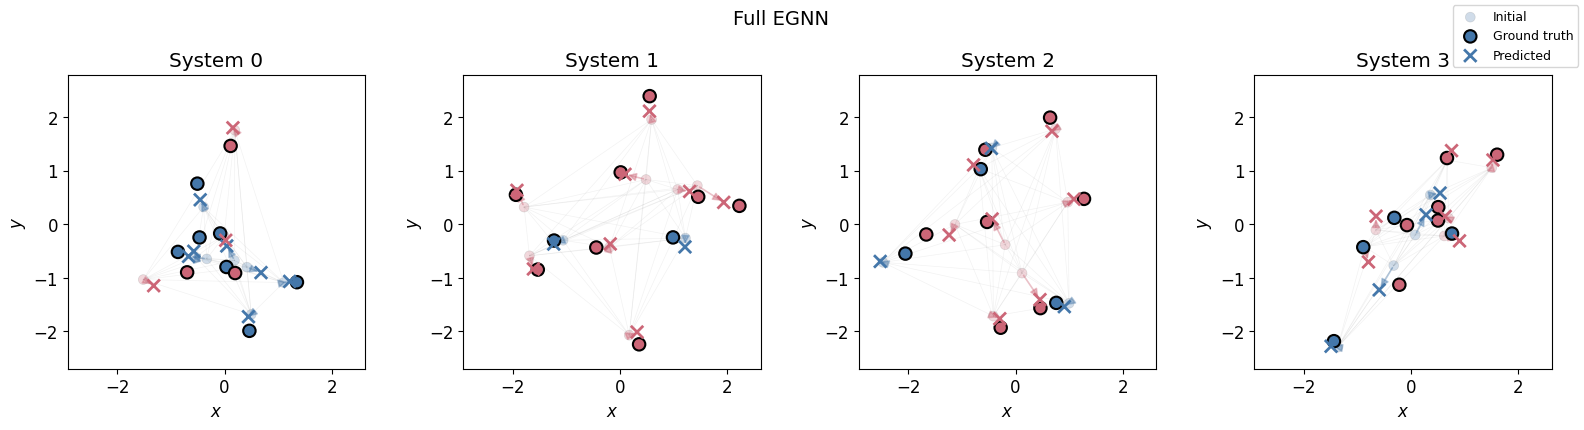

In [35]:
plot_trajectories(model_full, params_full, val_data, title="Full EGNN")

---
## 6. Equivariance Test

A key property of the EGNN is **rotational equivariance**: if you rotate all input positions and velocities, the predicted positions should rotate the same way.

$$f(Rx, Rv) = R \cdot f(x, v)$$

Implement a test that checks this. The idea:
1. Pick a random 3D rotation matrix $R$
2. **Path A:** Run the model on the original inputs, then rotate the prediction
3. **Path B:** Rotate the inputs (positions and velocities), then run the model
4. Compare: if the model is equivariant, Path A $\approx$ Path B (up to floating-point precision)

Test each of your models. Which are equivariant and which aren't? Does equivariance correlate with performance?

In [36]:
# TODO: Implement an equivariance test

def test_equivariance(model, params, data, n_tests=20):
    """
    Tests rotational equivariance: f(Rx, Rv) == R * f(x, v)
    """
    # Isolate a single system (N particles, 3 dimensions)
    # We remove the batch dimension for the matrix multiplication logic
    pos = data["pos"][0]           # Shape: (N, 3)
    vel = data["vel"][0]           # Shape: (N, 3)
    h = data["node_feat"][0]       # Shape: (N, feature_dim)
    edges = data["edges"][0]       # Shape: (N, N)

    key = jr.PRNGKey(42)
    errors = []

    for i in range(n_tests):
        key, subkey = jr.split(key)
        
        # 1. Pick a random 3D rotation matrix R
        R = jr.orthogonal(subkey, 3) 

        # 2. Path A: Run the model on the original inputs, then rotate the prediction
        # Output is f(x, v)
        pred_raw = model.apply(params, h, pos, vel, edges)
        # Rotate output: R * f(x, v)
        path_a = jnp.dot(pred_raw, R.T)

        # 3. Path B: Rotate the inputs (positions and velocities), then run the model
        # Rotate inputs: Rx and Rv
        pos_rotated = jnp.dot(pos, R.T)
        vel_rotated = jnp.dot(vel, R.T)
        # Output is f(Rx, Rv)
        path_b = model.apply(params, h, pos_rotated, vel_rotated, edges)

        # 4. Compare: Path A ≈ Path B
        # Measure the mean absolute difference between the two paths
        mae = jnp.mean(jnp.abs(path_a - path_b))
        errors.append(mae)

    avg_error = jnp.mean(jnp.array(errors))
    
    print(f"Mean Difference: {avg_error:.2e}")
    
    return avg_error

---
## 7. Ablation Studies

Now the main event. Systematically ablate the EGNN by modifying components of the model and measuring the impact on both **accuracy** (validation MSE) and **equivariance**.

For each ablation, you'll need to create a modified version of the EGNN class (or add flags to control behavior). Some approaches:
- Copy the `EGNN` class and edit the relevant lines
- Add boolean flags to the class and use `if/else` to switch behavior
- Whatever is clearest for your code and report

See the assignment description for the list of required and suggested ablations. For each, train the model, evaluate it, test equivariance, and visualize predictions.

**Tip:** Keep a dictionary of results so you can compare everything at the end.

In [37]:
import egnn_no_equivariance
import egnn_no_velocity
import egnn_no_distance
import egnn_no_tanh
import egnn_no_residual
import egnn_improved

# --- Implement Equivariance Test using only jax/numpy ---
def test_equivariance(model, params, data, n_tests=20):
    key = jr.PRNGKey(42)
    node_feat = data["node_feat"][:n_tests]
    pos = data["pos"][:n_tests]
    vel = data["vel"][:n_tests]
    edges = data["edges"][:n_tests]
    
    # Generate random rotations using JAX
    keys = jr.split(key, n_tests)
    equiv_errors = []
    
    for i in range(n_tests):
        # Generate a random 3x3 rotation matrix using QR decomposition on a random normal matrix
        random_mat = jr.normal(keys[i], (3, 3))
        q, r = jnp.linalg.qr(random_mat)
        d = jnp.diag(r)
        ph = d / jnp.abs(d)
        rot = q * ph
        
        # Path A: model(x, v) then rotate prediction
        pred_pos_A = model.apply(params, node_feat[i:i+1], pos[i:i+1], vel[i:i+1], edges[i:i+1])
        pred_pos_A_rot = pred_pos_A @ rot.T
        
        # Path B: rotate inputs then apply model
        pos_rot = pos[i:i+1] @ rot.T
        vel_rot = vel[i:i+1] @ rot.T
        pred_pos_B = model.apply(params, node_feat[i:i+1], pos_rot, vel_rot, edges[i:i+1])
        
        error = jnp.mean(jnp.abs(pred_pos_A_rot - pred_pos_B))
        equiv_errors.append(float(error))
        
    return np.mean(equiv_errors)

# --- Train and Test all models ---
models = {
    "Full EGNN": EGNN(),
    "No Equiv": egnn_no_equivariance.EGNN(),
    "No Velocity": egnn_no_velocity.EGNN(),
    "No Distance": egnn_no_distance.EGNN(),
    "No Tanh": egnn_no_tanh.EGNN(),
    "No Residual": egnn_no_residual.EGNN(),
    "Improved": egnn_improved.EGNN(),
}

results = {}
for name, model in models.items():
    print(f"--- Training {name} ---")
    params, train_loss, val_loss = train_model(
        model, train_data, val_data, n_epochs=100, batch_size=64, lr=1e-3, seed=42
    )
    
    equiv_err = test_equivariance(model, params, val_data, n_tests=20)
    print(f"{name} Final Val MSE: {val_loss[-1]:.6f} | Equivariance Error: {equiv_err:.6e}")
    
    results[name] = {
        "val_mse": val_loss[-1],
        "val_loss_curve": val_loss,
        "train_loss_curve": train_loss,
        "params": params,
        "model": model,
        "equiv_err": equiv_err
    }


--- Training Full EGNN ---
Epoch   1 | Train MSE: 0.168809 | Val MSE: 0.172199
Epoch  20 | Train MSE: 0.107891 | Val MSE: 0.109484
Epoch  40 | Train MSE: 0.099040 | Val MSE: 0.100642
Epoch  60 | Train MSE: 0.078845 | Val MSE: 0.080442
Epoch  80 | Train MSE: 0.076899 | Val MSE: 0.078472
Epoch 100 | Train MSE: 0.075280 | Val MSE: 0.076625
Full EGNN Final Val MSE: 0.076625 | Equivariance Error: 8.301010e-07
--- Training No Equiv ---
Epoch   1 | Train MSE: 0.153212 | Val MSE: 0.154163
Epoch  20 | Train MSE: 0.092781 | Val MSE: 0.093241
Epoch  40 | Train MSE: 0.091855 | Val MSE: 0.092390
Epoch  60 | Train MSE: 0.091259 | Val MSE: 0.091723
Epoch  80 | Train MSE: 0.090462 | Val MSE: 0.090863
Epoch 100 | Train MSE: 0.089847 | Val MSE: 0.090328
No Equiv Final Val MSE: 0.090328 | Equivariance Error: 1.172894e-02
--- Training No Velocity ---
Epoch   1 | Train MSE: 0.179101 | Val MSE: 0.182899
Epoch  20 | Train MSE: 0.115896 | Val MSE: 0.117890
Epoch  40 | Train MSE: 0.106927 | Val MSE: 0.108896
E

---
## 8. Compare and Analyze

Bring all your results together:
- Summary table of validation MSE and equivariance error for each model
- Learning curves (all models on one plot)
- Equivariance tests
- Trajectory visualizations for the best and worst models
- Any other analysis that helps tell the story (e.g., per-particle error scatter, error vs. displacement magnitude)

Model           | Val MSE      | Equiv Error
---------------------------------------------
Improved        | 0.009215     | 8.456005e-07
Full EGNN       | 0.076625     | 8.301010e-07
No Residual     | 0.078067     | 7.287800e-07
No Velocity     | 0.086271     | 7.663120e-07
No Equiv        | 0.090328     | 1.172894e-02
No Distance     | 0.106841     | 7.506237e-07
No Tanh         | 26.082621    | 1.087394e-04


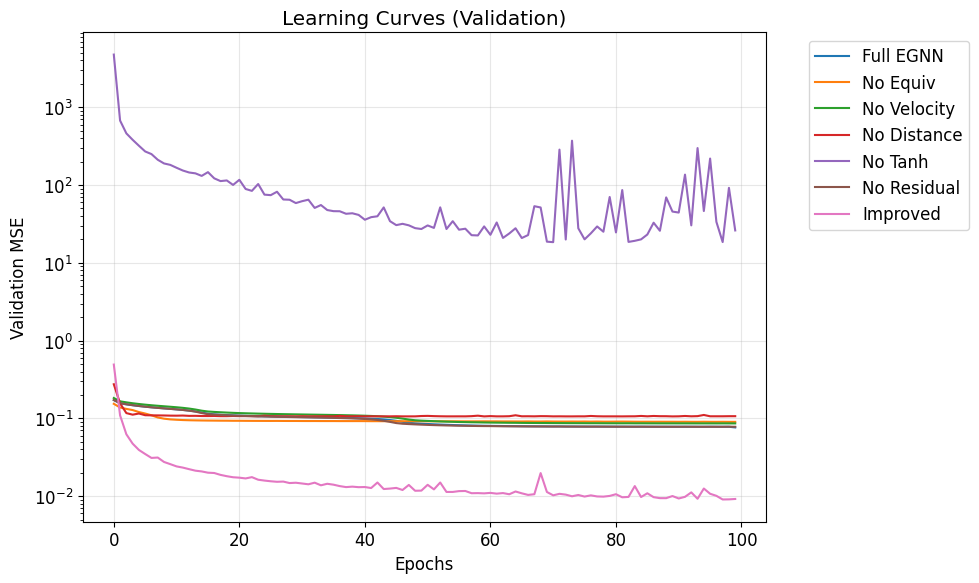

[Improved] - Best Model Trajectories:


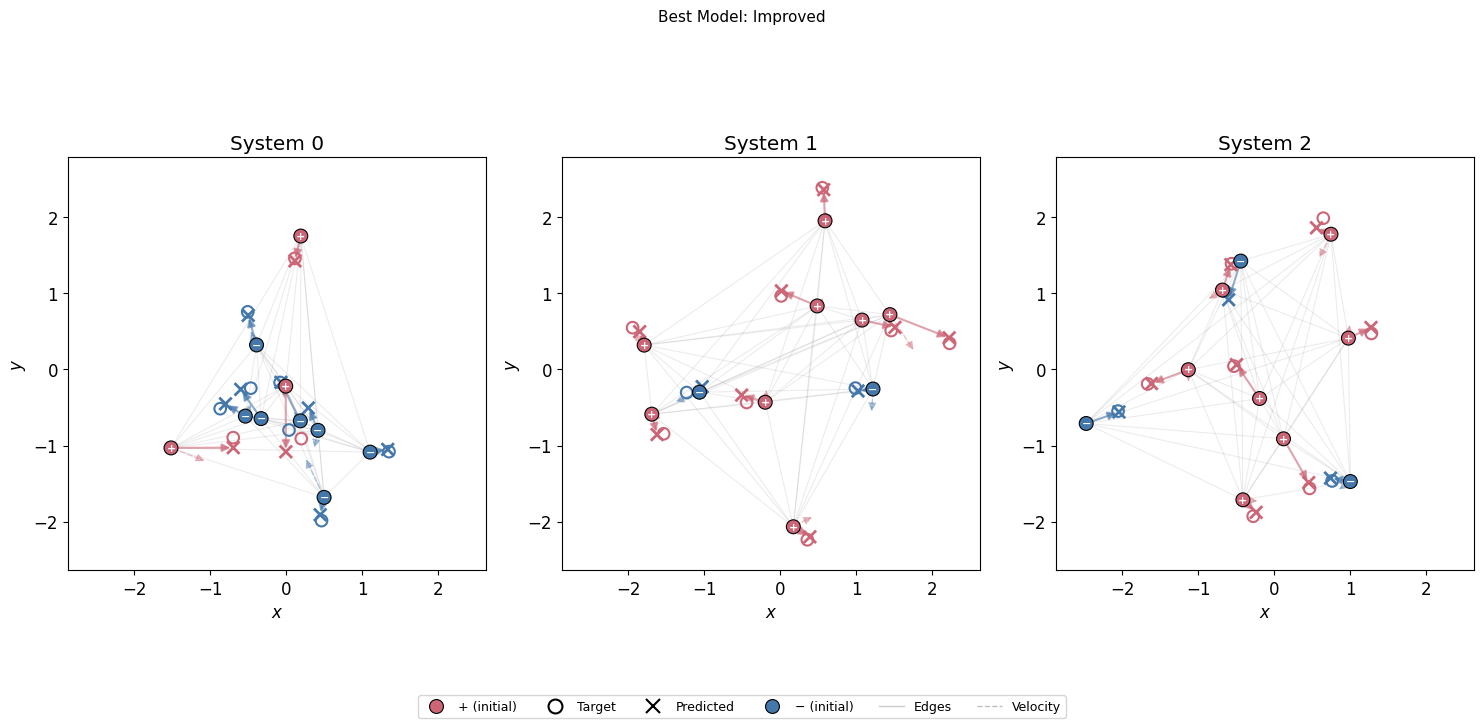

[No Tanh] - Worst Model Trajectories:


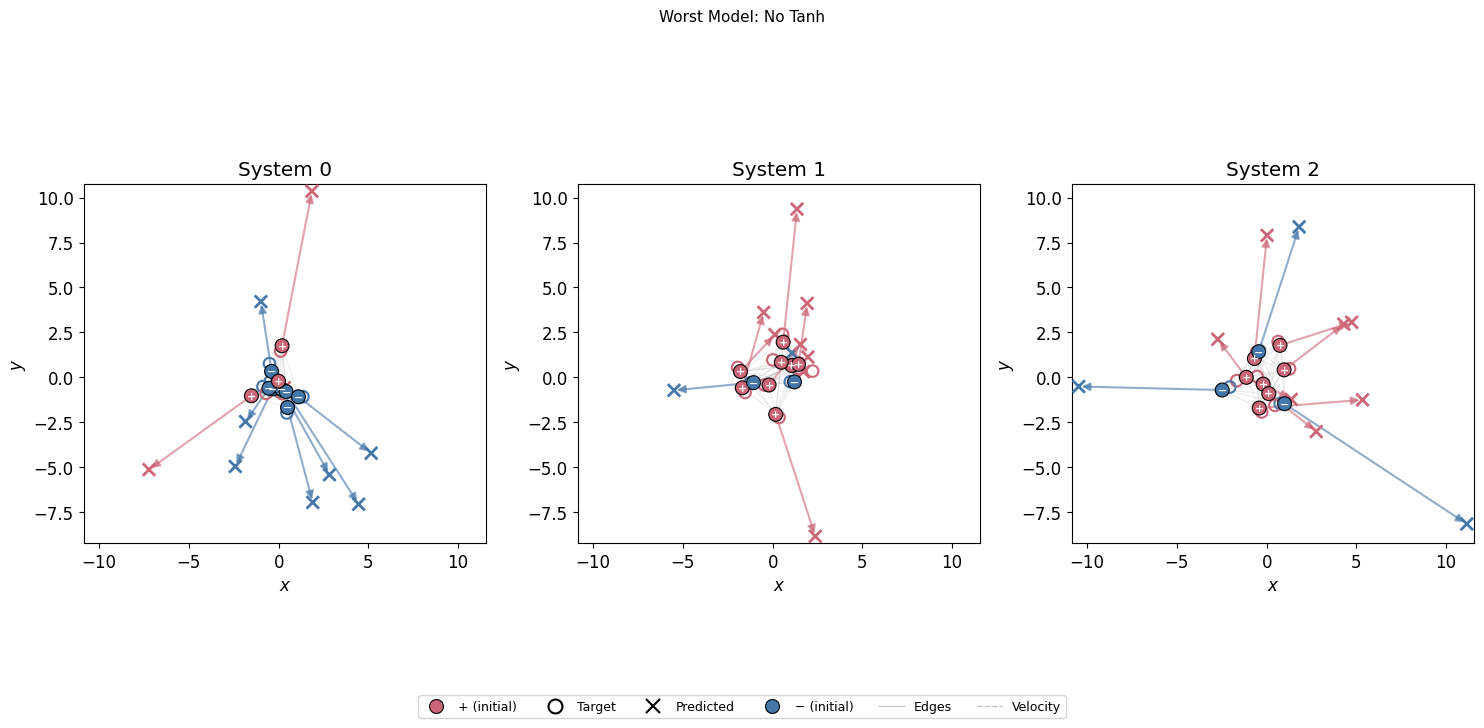

In [38]:
from matplotlib.lines import Line2D

# 1. Print Summary Table
print(f"{'Model':<15} | {'Val MSE':<12} | {'Equiv Error'}")
print("-" * 45)
# Sort results by validation MSE
sorted_results = sorted(results.items(), key=lambda x: x[1]['val_mse'])
for name, res in sorted_results:
    print(f"{name:<15} | {res['val_mse']:<12.6f} | {res['equiv_err']:.6e}")

# 2. Plot Learning Curves
plt.figure(figsize=(10, 6))
for name, res in results.items():
    plt.plot(res["val_loss_curve"], label=f"{name}")
plt.xlabel("Epochs")
plt.ylabel("Validation MSE")
plt.title("Learning Curves (Validation)")
plt.yscale("log")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Visualize Trajectories Function (using provided format)
def plot_model_trajectories(model, params, data, n_show=3, title=""):
    pred = model.apply(
        params,
        data["node_feat"][:n_show],
        data["pos"][:n_show],
        data["vel"][:n_show],
        data["edges"][:n_show],
    )
    pred_np = np.array(pred)
    
    fig, axes = plt.subplots(1, n_show, figsize=(15, 6.5))

    # Compute shared axis limits
    all_pts = np.concatenate([
        data["pos"][:n_show].reshape(-1, 3), 
        data["target_pos"][:n_show].reshape(-1, 3),
        pred_np.reshape(-1, 3)
    ], axis=0)
    
    pad = 0.4
    xlim = (all_pts[:, 0].min() - pad, all_pts[:, 0].max() + pad)
    ylim = (all_pts[:, 1].min() - pad, all_pts[:, 1].max() + pad)

    for idx, ax in enumerate(axes):
        pos_i = data["pos"][idx]
        vel_i = data["vel"][idx]
        target_i = data["target_pos"][idx]
        pred_i = pred_np[idx]
        charges_i = data["node_feat"][idx][:, 1] - data["node_feat"][idx][:, 0]
        n = len(pos_i)

        colors = ["#4477AA" if q < 0 else "#CC6677" for q in charges_i]

        # Edges
        for i in range(n):
            for j in range(i + 1, n):
                ax.plot([pos_i[i, 0], pos_i[j, 0]], [pos_i[i, 1], pos_i[j, 1]], color="gray", alpha=0.15, lw=0.8, zorder=1)

        # Displacement arrows: initial → PREDICTED
        for j in range(n):
            ax.annotate(
                "",
                xy=(pred_i[j, 0], pred_i[j, 1]),
                xytext=(pos_i[j, 0], pos_i[j, 1]),
                arrowprops=dict(arrowstyle="-|>", color=colors[j], lw=1.5, alpha=0.6),
            )

        # Velocity arrows (dashed)
        vel_scale = 2.0
        for j in range(n):
            ax.annotate(
                "",
                xy=(pos_i[j, 0] + vel_i[j, 0] * vel_scale, pos_i[j, 1] + vel_i[j, 1] * vel_scale),
                xytext=(pos_i[j, 0], pos_i[j, 1]),
                arrowprops=dict(arrowstyle="-|>", color=colors[j], lw=1.0, linestyle="dashed", alpha=0.4),
            )

        # Target positions (open circles)
        ax.scatter(
            target_i[:, 0], target_i[:, 1], s=70, marker="o", facecolors="none",
            edgecolors=colors, linewidths=1.5, zorder=4,
        )
        
        # Predicted positions (Xs)
        ax.scatter(
            pred_i[:, 0], pred_i[:, 1], c=colors, s=80, marker="x", 
            linewidths=2, zorder=5
        )

        # Initial positions (filled circles)
        ax.scatter(pos_i[:, 0], pos_i[:, 1], c=colors, s=100, zorder=5, edgecolors="black", linewidths=0.8)

        # Charge labels
        for j in range(n):
            label = "+" if charges_i[j] > 0 else "\u2212"
            ax.annotate(
                label, (pos_i[j, 0], pos_i[j, 1]), fontsize=8, fontweight="bold",
                ha="center", va="center", color="white", zorder=6,
            )

        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_xlabel(r"$x$")
        ax.set_ylabel(r"$y$")
        ax.set_title(f"System {idx}")
        ax.set_aspect("equal")

    legend_elements = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#CC6677", markersize=10, markeredgecolor="black", markeredgewidth=0.8, label="+ (initial)"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="w", markersize=10, markeredgecolor="black", markeredgewidth=1.5, label="Target"),
        Line2D([0], [0], marker="x", color="w", markeredgecolor="black", markersize=10, markeredgewidth=1.5, label="Predicted"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#4477AA", markersize=10, markeredgecolor="black", markeredgewidth=0.8, label="\u2212 (initial)"),
        Line2D([0], [0], color="gray", alpha=0.4, lw=1, label="Edges"),
        Line2D([0], [0], color="gray", lw=1, linestyle="dashed", alpha=0.5, label="Velocity"),
    ]
    
    fig.legend(handles=legend_elements, loc="lower center", ncol=6, fontsize=9, bbox_to_anchor=(0.5, -0.08))
    plt.suptitle(title, fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

# Get best and worst models
best_name = sorted_results[0][0]
worst_name = sorted_results[-1][0]

# Visualize Best
print(f"[{best_name}] - Best Model Trajectories:")
plot_model_trajectories(results[best_name]['model'], results[best_name]['params'], val_data, n_show=3, title=f"Best Model: {best_name}")

# Visualize Worst
print(f"[{worst_name}] - Worst Model Trajectories:")
plot_model_trajectories(results[worst_name]['model'], results[worst_name]['params'], val_data, n_show=3, title=f"Worst Model: {worst_name}")
